In [174]:
import pandas as pd

sleep_df = pd.read_csv("sleep_health_data.csv")
sleep_df['BMI Category'].unique()

array(['Overweight', 'Normal', 'Obese', 'Normal Weight'], dtype=object)

In [176]:
# Merge "Normal" and "Normal Weight"
sleep_df["BMI Category"] = sleep_df["BMI Category"].replace("Normal Weight", "Normal")

sleep_df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [151]:
# Q1: Which occupation has the lowest average sleep duration?
sleep_duration = sleep_df.groupby('Occupation')['Sleep Duration'].mean()
lowest_sleep_occ = sleep_duration.sort_values().index[0]
lowest_sleep_hrs = round(sleep_duration.min(), 2)
print(f"Q1: {lowest_sleep_occ}s have the lowest average sleep duration at {lowest_sleep_hrs} hours per night.")

# Q2: Which occupation has the lowest average sleep quality?
sleep_quality = sleep_df.groupby('Occupation')['Quality of Sleep'].mean()
lowest_sleep_quality_occ = sleep_quality.sort_values().index[0]
lowest_sleep_score = round(sleep_quality.min(), 2)
print(f"Q2: {lowest_sleep_quality_occ}s report the lowest average sleep quality with a score of {lowest_sleep_score} out of 10.")

# Q3: Did the occupation with the lowest sleep duration also have the lowest sleep quality?
same_occ = lowest_sleep_occ == lowest_sleep_quality_occ
if same_occ:
    print(f"Q3: Yes — {lowest_sleep_occ}s had both the lowest sleep duration AND the lowest sleep quality.")
else:
    print(f"Q3: No — {lowest_sleep_occ}s slept the least, but {lowest_sleep_quality_occ}s had the worst sleep quality. They are different occupations.")

# Q4: How does BMI category affect insomnia rates?
def insomnia_rate(bmi_category):
    group = sleep_df[sleep_df["BMI Category"] == bmi_category]
    insomnia = group[group["Sleep Disorder"] == "Insomnia"]
    return round(len(insomnia) / len(group), 2)

normal_insomnia_ratio    = insomnia_rate("Normal")
overweight_insomnia_ratio = insomnia_rate("Overweight")
obese_insomnia_ratio     = insomnia_rate("Obese")

print(f"Q4: Among Normal BMI individuals, {normal_insomnia_ratio:.0%} suffer from insomnia.")
print(f"    Among Overweight individuals, {overweight_insomnia_ratio:.0%} suffer from insomnia.")
print(f"    Among Obese individuals, {obese_insomnia_ratio:.0%} suffer from insomnia.")
print(f"    This suggests that higher BMI is associated with a greater risk of insomnia.")

bmi_insomnia_ratios = {
    "Normal": normal_insomnia_ratio,
    "Overweight": overweight_insomnia_ratio,
    "Obese": obese_insomnia_ratio
}

Q1: Sales Representatives have the lowest average sleep duration at 5.9 hours per night.
Q2: Sales Representatives report the lowest average sleep quality with a score of 4.0 out of 10.
Q3: Yes — Sales Representatives had both the lowest sleep duration AND the lowest sleep quality.
Q4: Among Normal BMI individuals, 4% suffer from insomnia.
    Among Overweight individuals, 43% suffer from insomnia.
    Among Obese individuals, 40% suffer from insomnia.
    This suggests that higher BMI is associated with a greater risk of insomnia.


Q5: We started to think, how can the blood pressure affect the sleep time and quality?

In [153]:
# Split blood pressure into two numeric columns
sleep_df[["BP Systolic", "BP Diastolic"]] = sleep_df["Blood Pressure"].str.split("/", expand=True).astype(int)

In [154]:
sleep_df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,BP Systolic,BP Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia,140,90
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia,140,90
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80


/var/folders/sk/0_m3z_mn0_s_52cww7x_mcf00000gn/T/ipykernel_48448/1284362615.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sleep_df, x="BMI Category", y="BP Systolic",


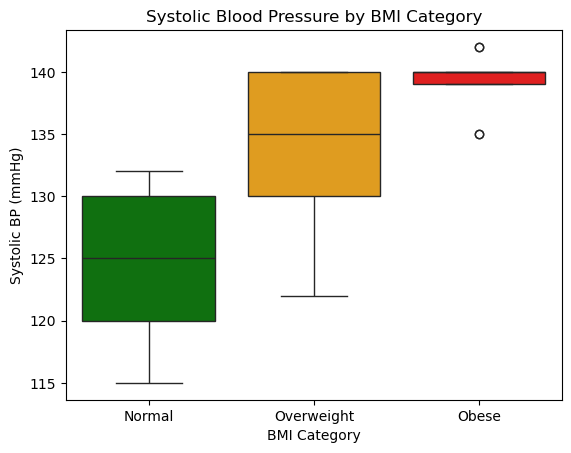

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=sleep_df, x="BMI Category", y="BP Systolic",
            order=["Normal","Overweight", "Obese"],
            palette=["green", "orange", "red"])
plt.title("Systolic Blood Pressure by BMI Category")
plt.ylabel("Systolic BP (mmHg)")
plt.show()

In [157]:
Q6: We found that the Obese people has the highest Systolic BP, so do they have the worse sleep quality?

Object `quality` not found.


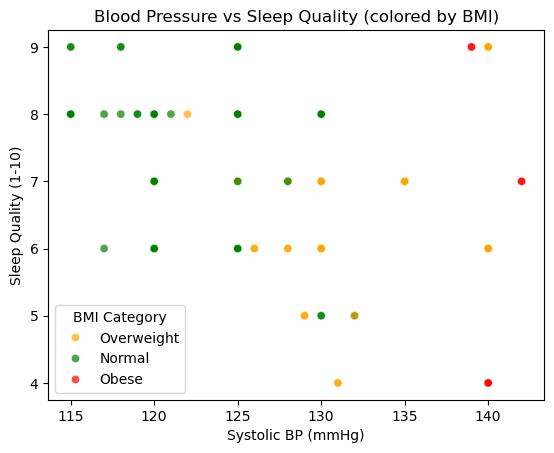

In [158]:
sns.scatterplot(data=sleep_df, 
                x="BP Systolic", 
                y="Quality of Sleep",
                hue="BMI Category", 
                alpha=0.7,
                palette={"Normal":"green", "Overweight":"orange", "Obese":"red"})


plt.title("Blood Pressure vs Sleep Quality (colored by BMI)")
plt.xlabel("Systolic BP (mmHg)")
plt.ylabel("Sleep Quality (1-10)")
plt.show()


From the chart above, Normal Weight individuals tend to have lower blood pressure and better sleep quality. As BP increases, sleep quality drops

Q7: Does taking a walk can be helpful for reducings stress and improving sleep quality?

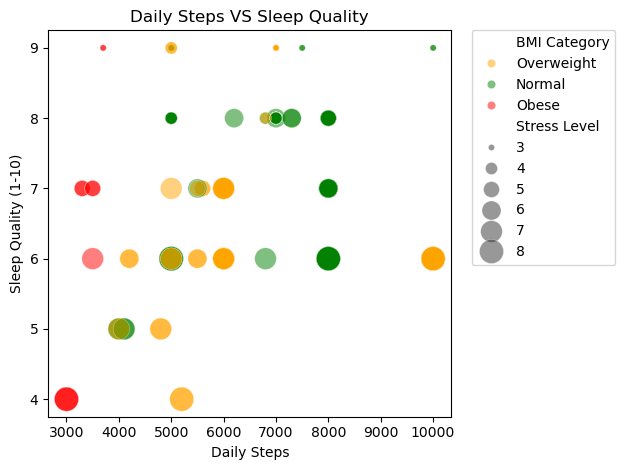

In [161]:
sns.scatterplot(data = sleep_df,
                x = "Daily Steps",
                y = "Quality of Sleep",
                size = "Stress Level",
                sizes = (20, 300),
                hue = "BMI Category",
                alpha = 0.5,
                palette = {"Normal":"green", "Overweight":"orange", "Obese":"red"})

plt.title("Daily Steps VS Sleep Quality")
plt.xlabel("Daily Steps")
plt.ylabel("Sleep Quality (1-10)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

From the chart above, individuals with more daily steps tend to have lower BMI and higher sleep quality. Taking more walks may help reduce stress and improve sleep quality.